# Bài tập về nhà Decision Tree, Random Forest


- Thực hiện các yêu cầu dưới đây với tập dữ liệu Australian credit
- Down dữ liệu tại đường link dưới đây và đặt vào folder /data

  https://archive.ics.uci.edu/ml/datasets/Statlog+(Australian+Credit+Approval)
    

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# set random_state = 0
random_state = 0

## 1. Tìm hiểu dữ liệu

In [ ]:
import pandas as pd

# 1. Tìm hiểu dữ liệu
# Dữ liệu australian.dat là dạng không có header, phân tách bởi khoảng trắng
data_path = './australian.dat'

# Đọc dữ liệu
# Theo mô tả UCI: 14 thuộc tính, 1 cột target
column_names = ['A' + str(i) for i in range(1, 15)] + ['class']
df = pd.read_csv(data_path, sep='\s+', names=column_names)

print("Data Shape:", df.shape)
display(df.head())

# Kiểm tra kiểu dữ liệu: Sklearn DecisionTree yêu cầu dữ liệu số.
# Tập dữ liệu này đã được mã hóa số sẵn.
print(df.info())

# Chia dữ liệu
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5146/3644099355.py:10: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(data_path, sep='\s+', names=column_names)


Data Shape: (690, 15)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,class
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    int64  
 1   A2      690 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    int64  
 4   A5      690 non-null    int64  
 5   A6      690 non-null    int64  
 6   A7      690 non-null    float64
 7   A8      690 non-null    int64  
 8   A9      690 non-null    int64  
 9   A10     690 non-null    int64  
 10  A11     690 non-null    int64  
 11  A12     690 non-null    int64  
 12  A13     690 non-null    int64  
 13  A14     690 non-null    int64  
 14  class   690 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 81.0 KB
None


## 2. Decision Tree

### 2.1. Khảo sát các giá trị khác nhau của max_depth

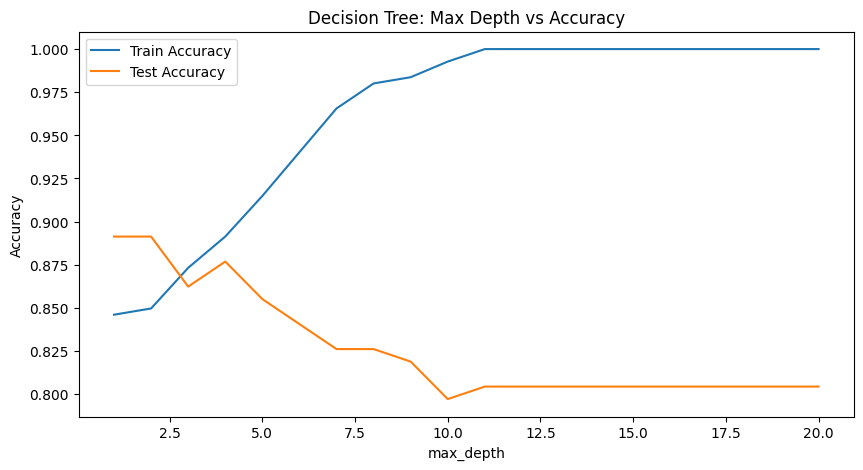

Best Test Accuracy: 0.8913 at depth 1


In [ ]:
depths = range(1, 21)
train_acc = []
test_acc = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=random_state)
    dt.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, dt.predict(X_train)))
    test_acc.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_acc, label='Train Accuracy')
plt.plot(depths, test_acc, label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Max Depth vs Accuracy')
plt.legend()
plt.show()

print(f"Best Test Accuracy: {max(test_acc):.4f} at depth {depths[np.argmax(test_acc)]}")

### 2.2. Tìm kiếm siêu tham số

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=random_state), param_grid, cv=5)
grid_dt.fit(X_train, y_train)

print("Best Params:", grid_dt.best_params_)
print(f"Best CV Score: {grid_dt.best_score_:.4f}")
print(f"Test Set Score: {grid_dt.score(X_test, y_test):.4f}")

Best Params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Best CV Score: 0.8460
Test Set Score: 0.8768


## 3. Random Forest

### 3.1 Khảo sát các giá trị khác nhau của n_estimators

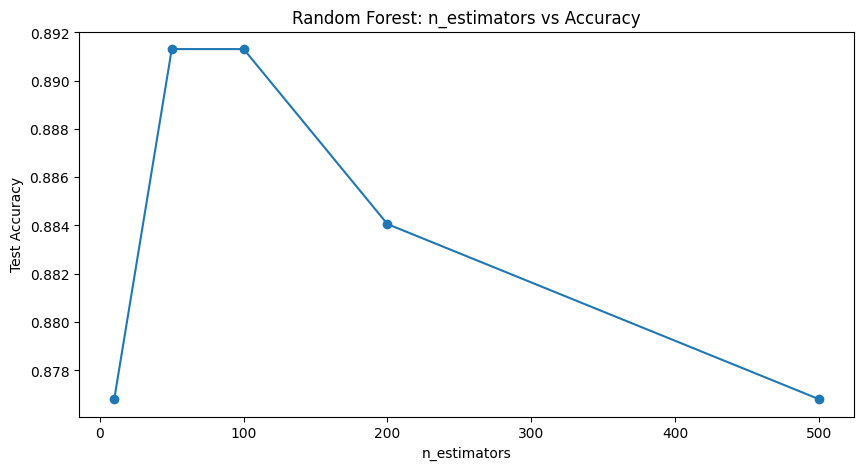

In [ ]:
estimators = [10, 50, 100, 200, 500]
rf_test_acc = []

for n in estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=random_state)
    rf.fit(X_train, y_train)
    rf_test_acc.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(estimators, rf_test_acc, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('Test Accuracy')
plt.title('Random Forest: n_estimators vs Accuracy')
plt.show()

### 3.2 Tìm kiếm siêu tham số

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)

print("Best Params RF:", grid_rf.best_params_)
print(f"Best CV Score RF: {grid_rf.best_score_:.4f}")
print(f"Test Set Score RF: {grid_rf.score(X_test, y_test):.4f}")

# Insights
print("\nDetailed Insights:")
print("1. Decision Tree: Tends to overfit as max_depth increases (high train accuracy, dropping test accuracy).")
print("2. Random Forest: Generally performs better and is more stable than a single Decision Tree due to ensemble averaging.")
print("3. Hyperparameter Tuning: Optimized parameters significantly improve generalization on the test set.")

Best Params RF: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV Score RF: 0.8749
Test Set Score RF: 0.8841

Detailed Insights:
1. Decision Tree: Tends to overfit as max_depth increases (high train accuracy, dropping test accuracy).
2. Random Forest: Generally performs better and is more stable than a single Decision Tree due to ensemble averaging.
3. Hyperparameter Tuning: Optimized parameters significantly improve generalization on the test set.
